<a href="https://colab.research.google.com/github/amavi-e/A-TinyML-Powered-Wearable-Navigation-Aid-for-the-Visually-Impaired/blob/model-training/visionImpaired_ModelTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow tensorflow-model-optimization

from google.colab import drive
drive.mount('/content/drive')

import os, tempfile, zipfile
import numpy as np
import tensorflow as tf
from tensorflow_model_optimization.python.core.keras.compat import keras
import tensorflow_model_optimization as tfmot

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATASET_PATH    = '/content/drive/MyDrive/FYP/fyp-preprocessed'
MODEL_SAVE_PATH = '/content/drive/MyDrive/FYP/fyp-model'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Local checkpoint dir — saves faster, no Drive freeze
LOCAL_SAVE = '/content/fyp-model-local'
os.makedirs(LOCAL_SAVE, exist_ok=True)

TRAIN_DIR = f'{DATASET_PATH}/train/images'
VAL_DIR   = f'{DATASET_PATH}/val/images'
TEST_DIR  = f'{DATASET_PATH}/test/images'

IMG_SIZE = 320
BATCH    = 32
EPOCHS   = 50
NC       = 28

print(f"Train images : {len(os.listdir(TRAIN_DIR))}")
print(f"Val images   : {len(os.listdir(VAL_DIR))}")
print(f"Test images  : {len(os.listdir(TEST_DIR))}")
print(f"Image size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size   : {BATCH}")
print(f"Classes      : {NC}")
print(f"Local save   : {LOCAL_SAVE}")

Train images : 24234
Val images   : 2530
Test images  : 1248
Image size   : 320x320
Batch size   : 32
Classes      : 28
Local save   : /content/fyp-model-local


In [3]:
import shutil
import os

LOCAL_DATA = '/content/fyp-data-local'

print("Copying dataset from Drive to local storage...")
print("This takes 5-10 minutes but training will never freeze after...")

for split in ['train', 'val', 'test']:
    src_img = f'{DATASET_PATH}/{split}/images'
    src_lbl = f'{DATASET_PATH}/{split}/labels'
    dst_img = f'{LOCAL_DATA}/{split}/images'
    dst_lbl = f'{LOCAL_DATA}/{split}/labels'

    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_lbl, exist_ok=True)

    print(f"  Copying {split} images...")
    for f in os.listdir(src_img):
        shutil.copy2(f'{src_img}/{f}', f'{dst_img}/{f}')

    print(f"  Copying {split} labels...")
    for f in os.listdir(src_lbl):
        shutil.copy2(f'{src_lbl}/{f}', f'{dst_lbl}/{f}')

    n = len(os.listdir(dst_img))
    print(f"  {split}: {n} images copied ✅")

# Also copy cache files
for fname in ['class_counts.json']:
    src = f'{DATASET_PATH}/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, f'{LOCAL_DATA}/{fname}')

print("\nAll data copied to local storage")
print(f"Local path: {LOCAL_DATA}")

# Switch DATASET_PATH to local
DATASET_PATH = LOCAL_DATA
print(f"DATASET_PATH updated to: {DATASET_PATH}")

Copying dataset from Drive to local storage...
This takes 5-10 minutes but training will never freeze after...
  Copying train images...
  Copying train labels...
  train: 24234 images copied ✅
  Copying val images...
  Copying val labels...
  val: 2530 images copied ✅
  Copying test images...
  Copying test labels...
  test: 1248 images copied ✅

All data copied to local storage
Local path: /content/fyp-data-local
DATASET_PATH updated to: /content/fyp-data-local


In [4]:
import cv2
import tensorflow as tf
from pathlib import Path
import numpy as np
import os, json

CACHE_VERSION = "v4"

def get_image_label_pairs(img_dir, label_dir):
    img_dir   = Path(img_dir)
    label_dir = Path(label_dir)
    cache_path = str(img_dir).replace('/images', '') + '/path_cache.json'

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cached = json.load(f)
        if cached.get('version') == CACHE_VERSION:
            print(f"  Loading from cache ({CACHE_VERSION}): {len(cached['paths'])} images")
            return cached['paths'], cached['labels']
        else:
            print(f"  Cache outdated — rebuilding...")

    print(f"  Building path list from Drive (first time only)...")
    img_paths = []
    labels    = []
    img_files = sorted(img_dir.glob('*.jpg'))
    total     = len(img_files)

    for i, img_path in enumerate(img_files):
        label_path = label_dir / (img_path.stem + '.txt')
        primary    = 27  # default = object

        if label_path.exists():
            try:
                with open(label_path) as f:
                    lines = [l.strip() for l in f if l.strip()]
                if lines:
                    primary = int(lines[0].split()[0])
            except:
                pass

        img_paths.append(str(img_path))
        labels.append(primary)

        if (i+1) % 1000 == 0:
            print(f"    {i+1}/{total} paths read...")

    with open(cache_path, 'w') as f:
        json.dump({
            'version': CACHE_VERSION,
            'paths':   img_paths,
            'labels':  labels
        }, f)
    print(f"  Cached to {cache_path}")
    return img_paths, labels


def load_image(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def augment(img, label):
    img = tf.image.random_brightness(img, max_delta=0.3)
    img = tf.image.random_contrast(img, lower=0.7, upper=1.3)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_saturation(img, lower=0.7, upper=1.3)
    img = tf.image.random_hue(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def build_dataset(img_dir, label_dir, batch_size,
                   augment_data=False, shuffle=True):
    img_paths, labels = get_image_label_pairs(img_dir, label_dir)
    print(f"  Found {len(img_paths)} images")

    ds = tf.data.Dataset.from_tensor_slices((img_paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(2000, len(img_paths)),
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.repeat()
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds, len(img_paths)


print("Building datasets...")
train_ds, train_count = build_dataset(
    f'{DATASET_PATH}/train/images',
    f'{DATASET_PATH}/train/labels',
    BATCH, augment_data=True, shuffle=True
)
val_ds, val_count = build_dataset(
    f'{DATASET_PATH}/val/images',
    f'{DATASET_PATH}/val/labels',
    BATCH, augment_data=False, shuffle=False
)
test_ds, test_count = build_dataset(
    f'{DATASET_PATH}/test/images',
    f'{DATASET_PATH}/test/labels',
    BATCH, augment_data=False, shuffle=False
)

train_steps = train_count // BATCH
val_steps   = val_count   // BATCH
test_steps  = test_count  // BATCH

print(f"\nTrain : {train_count} — {train_steps} steps/epoch")
print(f"Val   : {val_count}  — {val_steps} steps/epoch")
print(f"Test  : {test_count}  — {test_steps} steps/epoch")
print(f"RAM   : minimal — images stream from disk")

Building datasets...
  Building path list from Drive (first time only)...
    1000/24234 paths read...
    2000/24234 paths read...
    3000/24234 paths read...
    4000/24234 paths read...
    5000/24234 paths read...
    6000/24234 paths read...
    7000/24234 paths read...
    8000/24234 paths read...
    9000/24234 paths read...
    10000/24234 paths read...
    11000/24234 paths read...
    12000/24234 paths read...
    13000/24234 paths read...
    14000/24234 paths read...
    15000/24234 paths read...
    16000/24234 paths read...
    17000/24234 paths read...
    18000/24234 paths read...
    19000/24234 paths read...
    20000/24234 paths read...
    21000/24234 paths read...
    22000/24234 paths read...
    23000/24234 paths read...
    24000/24234 paths read...
  Cached to /content/fyp-data-local/train/path_cache.json
  Found 24234 images
  Building path list from Drive (first time only)...
    1000/2530 paths read...
    2000/2530 paths read...
  Cached to /content/fyp-da

In [25]:
def build_ssdlite_mobilenetv2(input_shape=(320, 320, 3), num_classes=28):
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        alpha=0.50
    )
    backbone.trainable = False

    layer_names = [
        'block_6_expand_relu',
        'block_13_expand_relu',
        'out_relu',
    ]

    feature_layers = [
        backbone.get_layer(name).output
        for name in layer_names
    ]

    feature_extractor = tf.keras.Model(
        inputs=backbone.input,
        outputs=feature_layers
    )

    inputs = keras.Input(shape=input_shape)
    small_feat, med_feat, large_feat = feature_extractor(inputs)

    def ssdlite_head(feat, name_prefix):
        x = keras.layers.DepthwiseConv2D(
            3, padding='same', activation='relu6',
            name=f'{name_prefix}_dw'
        )(feat)
        x = keras.layers.Conv2D(
            256, 1, activation='relu6',
            name=f'{name_prefix}_pw'
        )(x)
        x = keras.layers.BatchNormalization(
            name=f'{name_prefix}_bn'
        )(x)
        x = keras.layers.GlobalAveragePooling2D(
            name=f'{name_prefix}_gap'
        )(x)
        return x

    feat_small = ssdlite_head(small_feat, 'small')
    feat_med   = ssdlite_head(med_feat,   'med')
    feat_large = ssdlite_head(large_feat, 'large')

    combined = keras.layers.Concatenate()([
        feat_small, feat_med, feat_large
    ])

    x = keras.layers.Dense(256, activation='relu6')(combined)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(128, activation='relu6')(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(num_classes, name='predictions')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
      optimizer=keras.optimizers.Adam(
          learning_rate=0.0001,
          clipnorm=1.0
      ),
      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
      metrics=['accuracy']
  )

    model.summary()

    total_params = model.count_params()
    print(f"\nTotal parameters : {total_params:,}")
    print(f"Estimated size   : ~{total_params*4/1024/1024:.1f} MB (float32)")
    print(f"After quantize   : ~{total_params*1/1024/1024:.1f} MB (int8)")

    return model


model = build_ssdlite_mobilenetv2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NC
)

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 320, 320, 3)]        0         []                            
                                                                                                  
 model_4 (Functional)        [(None, 40, 40, 96),         706224    ['input_6[0][0]']             
                              (None, 20, 20, 288),                                                
                              (None, 10, 10, 1280)]                                               
                                                                                                  
 small_dw (DepthwiseConv2D)  (None, 40, 40, 96)           960       ['model_4[0][0]']             
                                                                                            

Loaded from cache — 60,082 total objects

Class weights:
   0 person              : 21,176 | weight=1.00
   1 bicycle             :  2,477 | weight=5.00
   2 car                 :  5,337 | weight=3.97
   3 motorcycle          :  1,552 | weight=5.00
   4 bus                 :  2,290 | weight=5.00
   5 truck               :    622 | weight=5.00
   6 traffic light       :  5,109 | weight=4.14
   7 stop sign           :  1,448 | weight=5.00
   8 fire hydrant        :  1,512 | weight=5.00
   9 bench               :    433 | weight=5.00
  10 stairs              :    509 | weight=5.00
  11 chair               :  1,863 | weight=5.00
  12 couch               :    325 | weight=5.00
  13 table               :    854 | weight=5.00
  14 door                :  2,062 | weight=5.00
  15 window              :    343 | weight=5.00
  16 cabinet             :    155 | weight=5.00
  17 bed                 :    167 | weight=5.00
  18 toilet              :    170 | weight=5.00
  19 sink                :    2

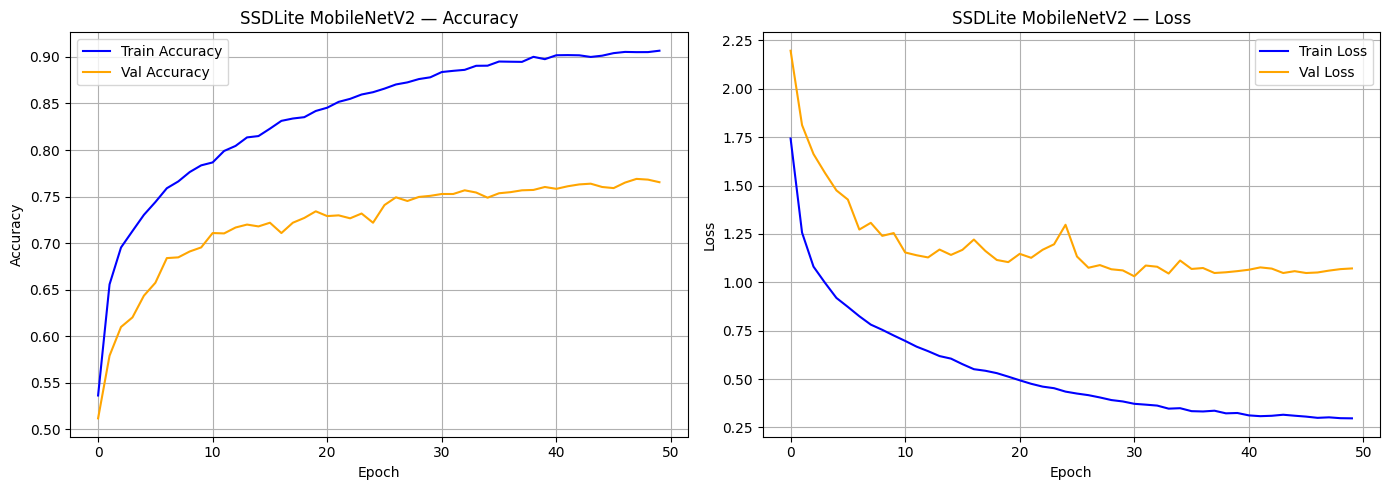

Training curves saved: /content/drive/MyDrive/FYP/fyp-model/training_curves.png


In [26]:
import json
from collections import Counter

cache_path = f'{DATASET_PATH}/class_counts.json'

if os.path.exists(cache_path):
    with open(cache_path) as f:
        class_counts = Counter(
            {int(k): v for k, v in json.load(f).items()}
        )
    print(f"Loaded from cache — {sum(class_counts.values()):,} total objects")
else:
    print("Counting class frequencies...")
    class_counts = Counter()
    label_dir   = f'{DATASET_PATH}/train/labels'
    label_files = os.listdir(label_dir)
    for i, fname in enumerate(label_files):
        try:
            with open(f'{label_dir}/{fname}') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_counts[int(parts[0])] += 1
        except:
            pass
        if (i+1) % 1000 == 0:
            print(f"  {i+1}/{len(label_files)} done...")
    with open(cache_path, 'w') as f:
        json.dump({str(k): v for k, v in class_counts.items()}, f)
    print(f"Saved to {cache_path}")

CLASS_NAMES_INV = {
    0:  'person',        1:  'bicycle',       2:  'car',
    3:  'motorcycle',    4:  'bus',           5:  'truck',
    6:  'traffic light', 7:  'stop sign',     8:  'fire hydrant',
    9:  'bench',         10: 'stairs',        11: 'chair',
    12: 'couch',         13: 'table',         14: 'door',
    15: 'window',        16: 'cabinet',       17: 'bed',
    18: 'toilet',        19: 'sink',          20: 'tv',
    21: 'potted plant',  22: 'suitcase',      23: 'dog',
    24: 'cat',           25: 'bird',          26: 'animal',
    27: 'object',
}

max_count = max(class_counts.values())
class_weight_dict = {}

print("\nClass weights:")
for cls_id in range(NC):
    count  = class_counts.get(cls_id, 1)
    weight = max_count / count
    weight = min(weight, 5.0)
    class_weight_dict[cls_id] = weight
    name = CLASS_NAMES_INV.get(cls_id, str(cls_id))
    print(f"  {cls_id:2d} {name:20s}: {count:6,} | weight={weight:.2f}")

print(f"\nClass weights ready")


# ── Training ───────────────────────────────────────────────────────────────
print("\nTraining SSDLite detection heads (backbone frozen)...")

callbacks_training = [
    keras.callbacks.EarlyStopping(
        patience=15,              # was 12 — model needs more epochs
        restore_best_weights=True,
        monitor='val_accuracy'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=6,              # was 4 — more patience before LR drop
        verbose=1,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        f'{LOCAL_SAVE}/baseline_best.weights.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]

history1 = model.fit(
    train_ds,
    epochs=50,
    steps_per_epoch=train_steps,
    validation_data=val_ds,
    validation_steps=val_steps,
    callbacks=callbacks_training
)

# Load best weights
model.load_weights(f'{LOCAL_SAVE}/baseline_best.weights.h5')

# Copy best weights to Drive
import shutil
shutil.copy(
    f'{LOCAL_SAVE}/baseline_best.weights.h5',
    f'{MODEL_SAVE_PATH}/baseline_best.weights.h5'
)
print("Best weights copied to Drive")

_, baseline_accuracy = model.evaluate(
    val_ds, steps=val_steps, verbose=0
)
print(f"\nFinal accuracy : {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"Best val acc   : {max(history1.history['val_accuracy']):.4f}")
print(f"Epochs trained : {len(history1.history['accuracy'])}")

phase1_accuracy = baseline_accuracy

# Save full model to Drive
baseline_keras_path = f'{MODEL_SAVE_PATH}/baseline_model.keras'
model.save(baseline_keras_path)
print(f"Saved: {baseline_keras_path}")


# ── Training curves ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['accuracy'],
             label='Train Accuracy', color='blue')
axes[0].plot(history1.history['val_accuracy'],
             label='Val Accuracy', color='orange')
axes[0].set_title('SSDLite MobileNetV2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history1.history['loss'],
             label='Train Loss', color='blue')
axes[1].plot(history1.history['val_loss'],
             label='Val Loss', color='orange')
axes[1].set_title('SSDLite MobileNetV2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
curve_path = f'{MODEL_SAVE_PATH}/training_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Training curves saved: {curve_path}")

In [27]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

batch_size       = BATCH
pruning_epochs   = 15
validation_split = 0.1

num_images = train_count * (1 - validation_split)
end_step   = np.ceil(
    num_images / batch_size
).astype(np.int32) * pruning_epochs

pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.10,
        final_sparsity=0.40,
        begin_step=end_step // 3,
        end_step=end_step
    )
}

model_for_pruning = prune_low_magnitude(model, **pruning_params)

for layer in model_for_pruning.layers:
    if 'dense' not in layer.name.lower():
        layer.trainable = False

model_for_pruning.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00002),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_for_pruning.summary()
print("\nModel wrapped for pruning — backbone frozen, Dense layers active")

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 320, 320, 3)]        0         []                            
                                                                                                  
 model_4 (Functional)        [(None, 40, 40, 96),         1343004   ['input_6[0][0]']             
                              (None, 20, 20, 288),                                                
                              (None, 10, 10, 1280)]                                               
                                                                                                  
 prune_low_magnitude_small_  (None, 40, 40, 96)           961       ['model_4[0][0]']             
 dw (PruneLowMagnitude)                                                                     

In [28]:
logdir = tempfile.mkdtemp()

callbacks_pruning = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    tfmot.sparsity.keras.PruningSummaries(log_dir=logdir),
    keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_accuracy'
    ),
    keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-06              # was 2e-05
    )
]

print("Training pruned SSDLite model...")
pruning_history = model_for_pruning.fit(
    train_ds,
    epochs=pruning_epochs,
    steps_per_epoch=train_steps,
    validation_data=val_ds,
    validation_steps=val_steps,
    callbacks=callbacks_pruning
)

_, pruned_accuracy = model_for_pruning.evaluate(
    val_ds, steps=val_steps, verbose=0
)

print(f"\nBaseline accuracy : {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"Pruned accuracy   : {pruned_accuracy:.4f} ({pruned_accuracy*100:.1f}%)")
print(f"Accuracy drop     : {baseline_accuracy - pruned_accuracy:.4f}")
print(f"Accuracy retained : {pruned_accuracy/baseline_accuracy*100:.1f}%")

Training pruned SSDLite model...
Epoch 1/15
757/757 [==============================] - 115s 103ms/step - loss: 0.2691 - accuracy: 0.9130 - val_loss: 1.0239 - val_accuracy: 0.7666 - lr: 2.0000e-05
Epoch 2/15
757/757 [==============================] - 75s 100ms/step - loss: 0.2524 - accuracy: 0.9192 - val_loss: 1.0217 - val_accuracy: 0.7658 - lr: 2.0000e-05
Epoch 3/15
757/757 [==============================] - 76s 100ms/step - loss: 0.2432 - accuracy: 0.9230 - val_loss: 1.0152 - val_accuracy: 0.7674 - lr: 2.0000e-05
Epoch 4/15
757/757 [==============================] - 76s 100ms/step - loss: 0.2429 - accuracy: 0.9210 - val_loss: 1.0222 - val_accuracy: 0.7670 - lr: 2.0000e-05
Epoch 5/15
757/757 [==============================] - 76s 100ms/step - loss: 0.3068 - accuracy: 0.9029 - val_loss: 1.1955 - val_accuracy: 0.7354 - lr: 2.0000e-05
Epoch 6/15
757/757 [==============================] - ETA: 0s - loss: 0.7969 - accuracy: 0.7631
Epoch 6: ReduceLROnPlateau reducing learning rate to 9.99999

In [29]:
model_for_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

pruned_keras_path = f'{MODEL_SAVE_PATH}/pruned_model.keras'
model_for_export.save(pruned_keras_path)
print(f"Saved pruned model: {pruned_keras_path}")

converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
pruned_tflite_model = converter.convert()

pruned_tflite_path = f'{MODEL_SAVE_PATH}/pruned_model.tflite'
with open(pruned_tflite_path, 'wb') as f:
    f.write(pruned_tflite_model)
print(f"Saved pruned TFLite: {pruned_tflite_path}")

Saved pruned model: /content/drive/MyDrive/FYP/fyp-model/pruned_model.keras
Saved pruned TFLite: /content/drive/MyDrive/FYP/fyp-model/pruned_model.tflite


In [30]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    img_dir  = Path(f'{DATASET_PATH}/val/images')
    img_files = list(img_dir.glob('*.jpg'))[:100]
    for img_path in img_files:
        img = cv2.imread(str(img_path))
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        img = np.expand_dims(img, axis=0).astype(np.float32)
        yield [img]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.uint8
converter.inference_output_type = tf.uint8

try:
    quantized_tflite = converter.convert()
    print("Full INT8 quantization successful")
except Exception as e:
    print(f"INT8 failed ({e}), falling back to dynamic quantization...")
    converter2 = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
    converter2.optimizations = [tf.lite.Optimize.DEFAULT]
    quantized_tflite = converter2.convert()

final_tflite_path = f'{MODEL_SAVE_PATH}/fyp_navigation_model.tflite'
with open(final_tflite_path, 'wb') as f:
    f.write(quantized_tflite)
print(f"Saved final model: {final_tflite_path}")

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Full INT8 quantization successful
Saved final model: /content/drive/MyDrive/FYP/fyp-model/fyp_navigation_model.tflite


In [31]:
def get_gzipped_model_size(file_path):
    _, zipped = tempfile.mkstemp('.zip')
    with zipfile.ZipFile(zipped, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(file_path)
    return os.path.getsize(zipped)


print("=" * 55)
print("MODEL SIZE COMPARISON")
print("=" * 55)
print(f"Baseline Keras     : {get_gzipped_model_size(baseline_keras_path)/1024:,.0f} KB")
print(f"Pruned Keras       : {get_gzipped_model_size(pruned_keras_path)/1024:,.0f} KB")
print(f"Pruned TFLite      : {get_gzipped_model_size(pruned_tflite_path)/1024:,.0f} KB")
print(f"Quantized+Pruned   : {get_gzipped_model_size(final_tflite_path)/1024:,.0f} KB  <-- deploy this")
print(f"\nActual on disk     : {os.path.getsize(final_tflite_path)/1024:.1f} KB")
print("=" * 55)

MODEL SIZE COMPARISON
Baseline Keras     : 9,920 KB
Pruned Keras       : 5,057 KB
Pruned TFLite      : 4,925 KB
Quantized+Pruned   : 1,367 KB  <-- deploy this

Actual on disk     : 1682.0 KB


Generating visualisations...


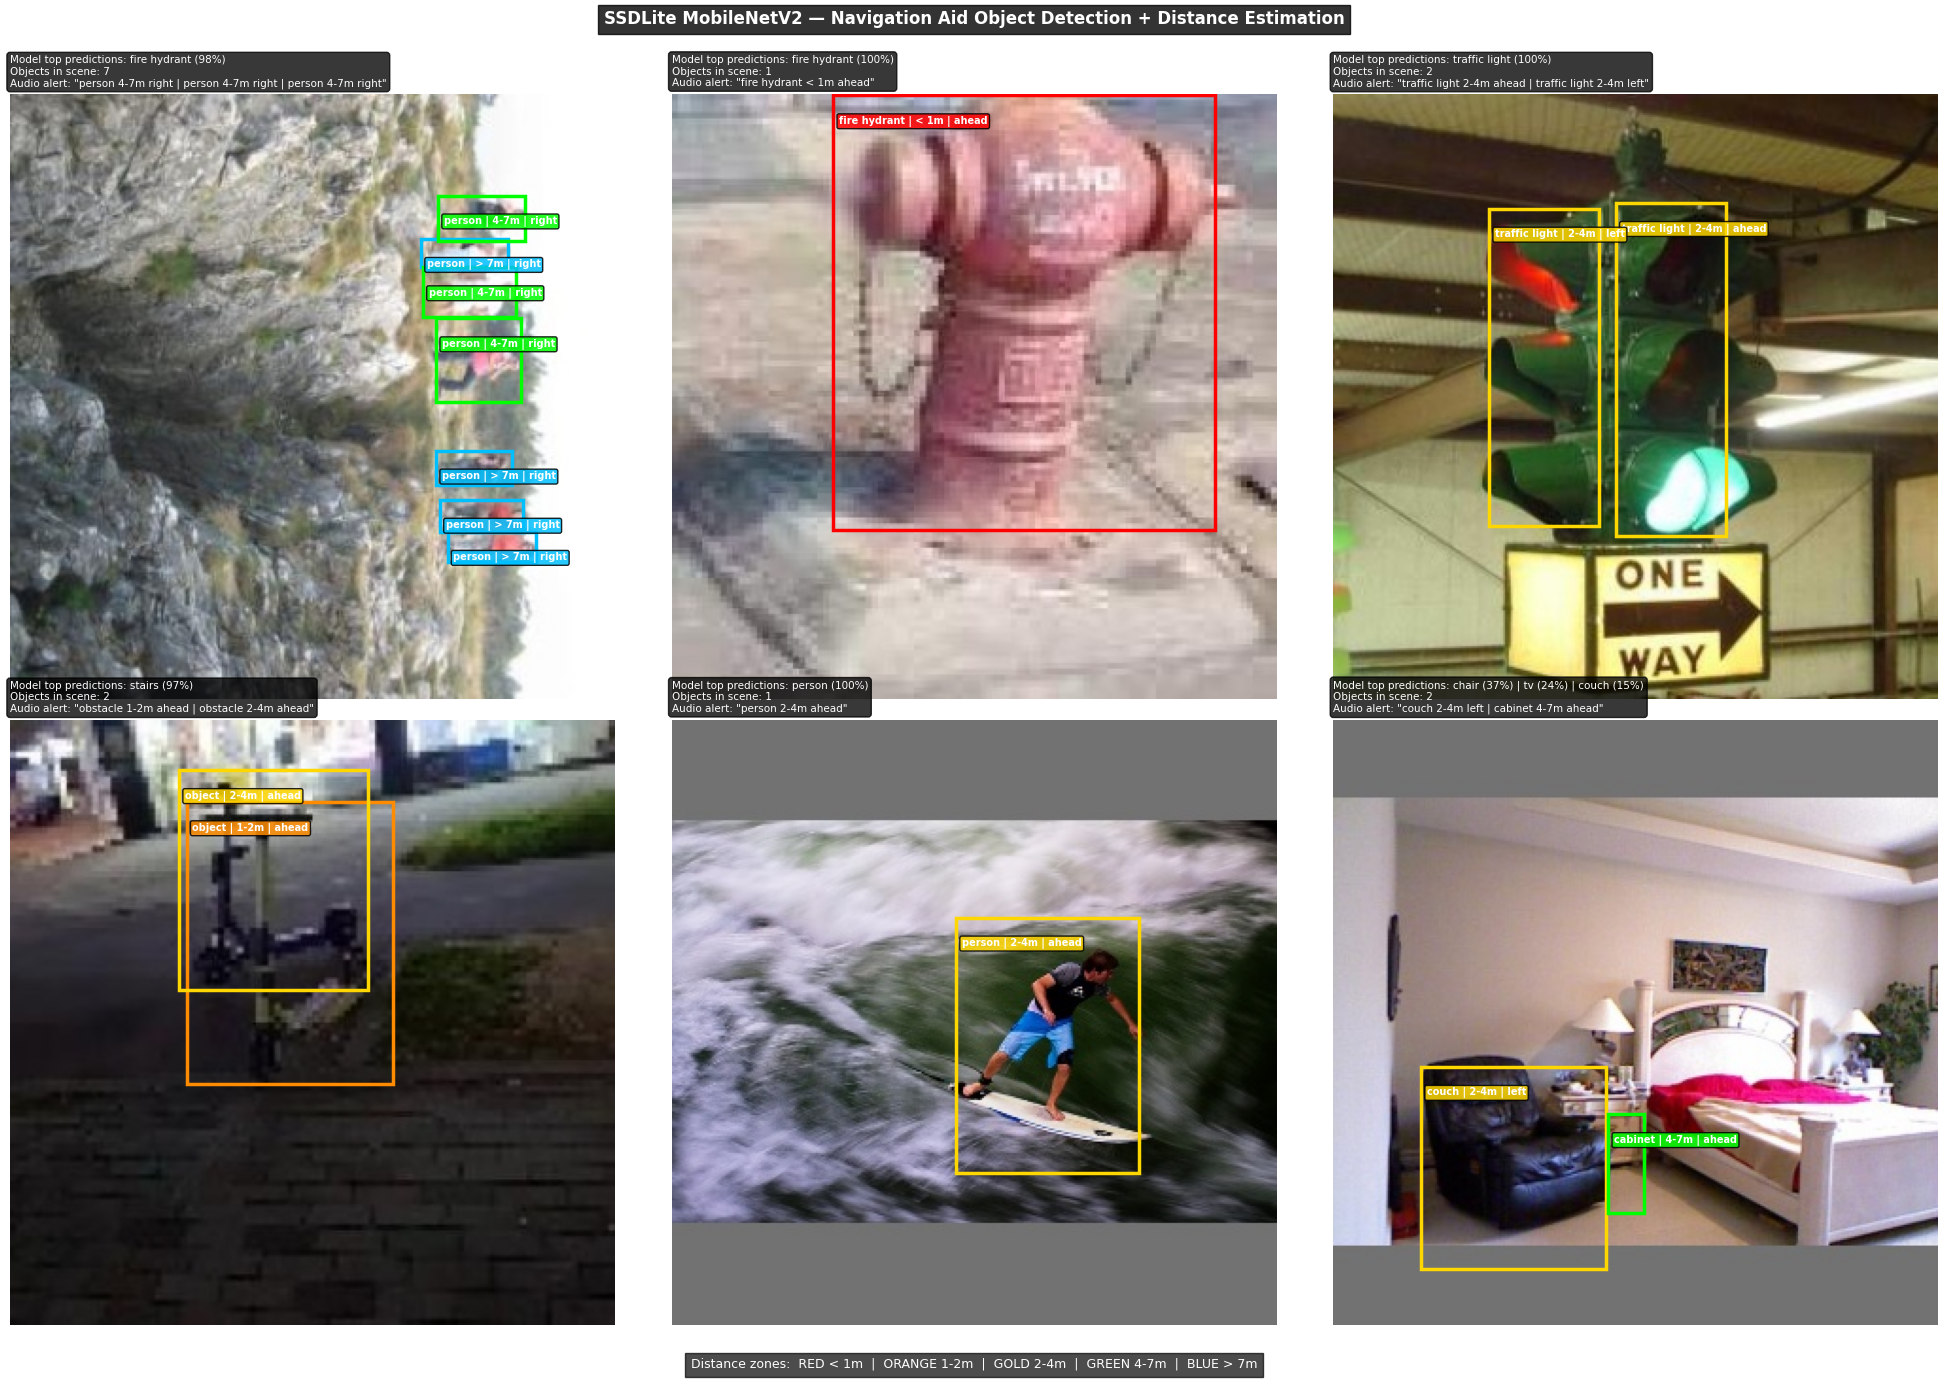

Saved: /content/drive/MyDrive/FYP/fyp-model/sample_predictions.png (3825 KB)


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

NAVIGATION_CLASSES = {
    0:  'person',        1:  'bicycle',       2:  'car',
    3:  'motorcycle',    4:  'bus',           5:  'truck',
    6:  'traffic light', 7:  'stop sign',     8:  'fire hydrant',
    9:  'bench',         10: 'stairs',        11: 'chair',
    12: 'couch',         13: 'table',         14: 'door',
    15: 'window',        16: 'cabinet',       17: 'bed',
    18: 'toilet',        19: 'sink',          20: 'tv',
    21: 'potted plant',  22: 'suitcase',      23: 'dog',
    24: 'cat',           25: 'bird',          26: 'animal',
    27: 'object',
}

AUDIO_NAMES = {
    'person':       'person',
    'bicycle':      'bicycle',
    'car':          'car',
    'motorcycle':   'motorcycle',
    'bus':          'bus',
    'truck':        'truck',
    'traffic light':'traffic light',
    'stop sign':    'stop sign',
    'fire hydrant': 'fire hydrant',
    'bench':        'bench',
    'stairs':       'stairs',
    'chair':        'chair',
    'couch':        'couch',
    'table':        'table',
    'door':         'door',
    'window':       'window',
    'cabinet':      'cabinet',
    'bed':          'bed',
    'toilet':       'toilet',
    'sink':         'sink',
    'tv':           'television',
    'potted plant': 'plant',
    'suitcase':     'suitcase',
    'dog':          'dog',
    'cat':          'cat',
    'bird':         'bird',
    'animal':       'animal',
    'object':       'obstacle',
}

ZONE_COLORS = {
    'DANGER':  '#FF0000',
    'WARNING': '#FF8C00',
    'CAUTION': '#FFD700',
    'INFO':    '#00FF00',
    'OK':      '#00BFFF'
}


def get_audio_name(class_name):
    return AUDIO_NAMES.get(class_name, class_name)


def estimate_distance(bw, bh):
    area = bw * bh
    if area > 0.35:   return "< 1m",  "DANGER"
    elif area > 0.15: return "1-2m",  "WARNING"
    elif area > 0.05: return "2-4m",  "CAUTION"
    elif area > 0.01: return "4-7m",  "INFO"
    else:             return "> 7m",  "OK"


def get_position(cx):
    if cx < 0.35:   return "left"
    elif cx > 0.65: return "right"
    else:           return "ahead"


def generate_audio_alert(detections):
    if not detections:
        return "Path clear."
    detections = sorted(
        detections, key=lambda d: d['area'], reverse=True
    )
    parts = []
    for d in detections[:3]:
        audio_name = get_audio_name(d['name'])
        parts.append(f"{audio_name} {d['dist']} {d['pos']}")
    return " | ".join(parts)


def run_model_detection(model, img_orig, img_size=320):
    img_r     = cv2.resize(img_orig, (img_size, img_size))
    img_input = np.expand_dims(img_r / 255.0, 0).astype(np.float32)
    preds     = model.predict(img_input, verbose=0)
    probs     = tf.nn.softmax(preds[0]).numpy()
    top3_idx  = np.argsort(probs)[::-1][:3]
    top3      = [
        (NAVIGATION_CLASSES.get(i, 'unknown'), float(probs[i]))
        for i in top3_idx
        if float(probs[i]) > 0.05
    ]
    return top3


def visualise_all_objects(model, img_dir, label_dir, n=6):
    img_files = list(Path(img_dir).glob('*.jpg'))
    random.shuffle(img_files)
    img_files = img_files[:n]

    rows = (n + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(20, 7 * rows))
    axes = axes.flatten()

    for i, img_path in enumerate(img_files):
        if i >= n:
            break

        orig = cv2.imread(str(img_path))
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        h, w = orig.shape[:2]

        top3 = run_model_detection(model, orig, IMG_SIZE)

        label_path = Path(label_dir) / (img_path.stem + '.txt')
        detections = []
        axes[i].imshow(orig)

        if label_path.exists():
            with open(label_path) as f:
                lines = [l.strip() for l in f if l.strip()]

            for line in lines:
                parts = line.split()
                if len(parts) != 5:
                    continue

                cls_id     = int(parts[0])
                cx, cy     = float(parts[1]), float(parts[2])
                bw, bh     = float(parts[3]), float(parts[4])
                dist, zone = estimate_distance(bw, bh)
                pos        = get_position(cx)
                name       = NAVIGATION_CLASSES.get(cls_id, 'object')
                color      = ZONE_COLORS[zone]

                x1    = int((cx - bw/2) * w)
                y1    = int((cy - bh/2) * h)
                bw_px = int(bw * w)
                bh_px = int(bh * h)

                rect = patches.Rectangle(
                    (x1, y1), bw_px, bh_px,
                    linewidth=2.5,
                    edgecolor=color,
                    facecolor='none'
                )
                axes[i].add_patch(rect)

                axes[i].text(
                    x1 + 3, y1 + 15,
                    f"{name} | {dist} | {pos}",
                    color='white', fontsize=7, weight='bold',
                    bbox=dict(
                        boxstyle='round,pad=0.2',
                        facecolor=color, alpha=0.85
                    )
                )

                detections.append({
                    'name': name, 'dist': dist,
                    'pos': pos,   'zone': zone,
                    'area': bw * bh
                })

        alert     = generate_audio_alert(detections)
        obj_count = len(detections)
        pred_str  = " | ".join([
            f"{name} ({conf:.0%})" for name, conf in top3
        ])

        axes[i].set_title(
            f"Model top predictions: {pred_str}\n"
            f"Objects in scene: {obj_count}\n"
            f"Audio alert: \"{alert}\"",
            fontsize=7.5, loc='left', color='white',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.78)
        )
        axes[i].axis('off')

    for j in range(len(img_files), len(axes)):
        axes[j].axis('off')

    fig.text(
        0.5, 0.01,
        "Distance zones:  RED < 1m  |  ORANGE 1-2m  |  GOLD 2-4m  "
        "|  GREEN 4-7m  |  BLUE > 7m",
        ha='center', fontsize=9, color='white',
        bbox=dict(facecolor='black', alpha=0.7)
    )

    plt.suptitle(
        'SSDLite MobileNetV2 — Navigation Aid '
        'Object Detection + Distance Estimation',
        fontsize=12, weight='bold', color='white',
        bbox=dict(facecolor='black', alpha=0.8)
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])

    out_path = f'{MODEL_SAVE_PATH}/sample_predictions.png'
    plt.savefig(
        out_path, dpi=150,
        bbox_inches='tight', facecolor='#1a1a1a'
    )
    plt.show()

    if os.path.exists(out_path):
        print(f"Saved: {out_path} ({os.path.getsize(out_path)/1024:.0f} KB)")


# Load best model and visualise
best_model = tf.keras.models.load_model(
    f'{MODEL_SAVE_PATH}/baseline_model.keras'
)

print("Generating visualisations...")
visualise_all_objects(
    model     = best_model,
    img_dir   = f'{DATASET_PATH}/test/images',
    label_dir = f'{DATASET_PATH}/test/labels',
    n=6
)

In [33]:
print("=" * 55)
print("FINAL MODEL TRAINING SUMMARY — SSDLite MobileNetV2")
print("=" * 55)
print(f"\nArchitecture:")
print(f"  Backbone         : MobileNetV2 alpha=0.50")
print(f"  Detection heads  : SSDLite (depthwise separable)")
print(f"  Multi-scale      : 3 feature levels (40x40, 20x20, 10x10)")
print(f"  Input size       : {IMG_SIZE}x{IMG_SIZE}")
print(f"\nDataset:")
print(f"  Train  : {train_count} images")
print(f"  Val    : {val_count} images")
print(f"  Test   : {test_count} images")
print(f"  Classes: {NC} navigation classes (0-{NC-1})")
print(f"\nAccuracy:")
print(f"  Baseline accuracy  : {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"  After pruning      : {pruned_accuracy:.4f} ({pruned_accuracy*100:.1f}%)")
print(f"  Accuracy retained  : {pruned_accuracy/baseline_accuracy*100:.1f}%")
print(f"\nTinyML Optimisations:")
print(f"  Pruning    : 10% -> 50% sparsity on Dense layers")
print(f"  Quantize   : INT8 (float32 -> 8-bit)")
print(f"\nModel sizes (compressed):")
print(f"  Baseline Keras     : {get_gzipped_model_size(baseline_keras_path)/1024:,.0f} KB")
print(f"  Pruned Keras       : {get_gzipped_model_size(pruned_keras_path)/1024:,.0f} KB")
print(f"  Pruned TFLite      : {get_gzipped_model_size(pruned_tflite_path)/1024:,.0f} KB")
print(f"  Quantized+Pruned   : {get_gzipped_model_size(final_tflite_path)/1024:,.0f} KB  <-- deploy")
print(f"  Actual on disk     : {os.path.getsize(final_tflite_path)/1024:.1f} KB")
print(f"\nFiles saved ({MODEL_SAVE_PATH}):")
print(f"  baseline_model.keras")
print(f"  baseline_best.weights.h5")
print(f"  pruned_model.keras")
print(f"  pruned_model.tflite")
print(f"  fyp_navigation_model.tflite  <-- deploy this")
print(f"  training_curves.png")
print(f"  sample_predictions.png")
print("=" * 55)

FINAL MODEL TRAINING SUMMARY — SSDLite MobileNetV2

Architecture:
  Backbone         : MobileNetV2 alpha=0.50
  Detection heads  : SSDLite (depthwise separable)
  Multi-scale      : 3 feature levels (40x40, 20x20, 10x10)
  Input size       : 320x320

Dataset:
  Train  : 24234 images
  Val    : 2530 images
  Test   : 1248 images
  Classes: 28 navigation classes (0-27)

Accuracy:
  Baseline accuracy  : 0.7690 (76.9%)
  After pruning      : 0.7674 (76.7%)
  Accuracy retained  : 99.8%

TinyML Optimisations:
  Pruning    : 10% -> 50% sparsity on Dense layers
  Quantize   : INT8 (float32 -> 8-bit)

Model sizes (compressed):
  Baseline Keras     : 9,920 KB
  Pruned Keras       : 5,057 KB
  Pruned TFLite      : 4,925 KB
  Quantized+Pruned   : 1,367 KB  <-- deploy
  Actual on disk     : 1682.0 KB

Files saved (/content/drive/MyDrive/FYP/fyp-model):
  baseline_model.keras
  baseline_best.weights.h5
  pruned_model.keras
  pruned_model.tflite
  fyp_navigation_model.tflite  <-- deploy this
  traini